# LangGraph — Two Nodes: Weather Agent vs Joke Generator

**Graph flow:**
```
START → router_node ──(weather)──→ weather_node → END
                    ↘(joke)──────→ joke_node    → END
```

#### Environment files ###

In [1]:
from dotenv import load_dotenv

env_path = "/Users/ahmedibrahim/Desktop/Mids/projects_2026/.env"
load_dotenv(env_path)

True

In [2]:
import os

openai_api_key = os.getenv("OPENAI_API_KEY")
open_weather_api_key = os.getenv("OPENWEATHER_API_KEY")

#### 2. Define the Shared State

In [3]:
from typing import TypedDict, Optional

class AgentState(TypedDict):
    user_input: str
    intent: str              # 'weather' or 'joke'
    city: Optional[str]      # only used by weather_node
    topic: Optional[str]     # only used by joke_node
    final_answer: Optional[str]

#### 3. Define the Three Nodes

In [4]:
from langchain_openai import ChatOpenAI
import requests

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

# ── Node 1: Router ───────────────────────────────────────────────────────────
def router_node(state: AgentState) -> AgentState:
    """Classifies intent as 'weather' or 'joke' and extracts key info."""
    prompt = f"""Classify this user message into one of two intents: weather or joke.

If it is about weather, respond:
  INTENT: weather
  CITY: <city name>

If it is asking for a joke (or anything funny), respond:
  INTENT: joke
  TOPIC: <topic of the joke, or 'general' if none specified>

If unsure, default to joke.

Message: {state['user_input']}"""

    response = llm.invoke(prompt).content.strip()
    print(f"[Router] →\n{response}\n")

    intent = "joke"
    city = None
    topic = "general"

    for line in response.splitlines():
        line = line.strip()
        if line.startswith("INTENT:"):
            intent = line.split(":", 1)[1].strip().lower()
        elif line.startswith("CITY:"):
            city = line.split(":", 1)[1].strip()
        elif line.startswith("TOPIC:"):
            topic = line.split(":", 1)[1].strip()

    return {**state, "intent": intent, "city": city, "topic": topic}


# ── Node 2: Weather Agent ────────────────────────────────────────────────────
def weather_node(state: AgentState) -> AgentState:
    """Fetches live weather and generates a friendly answer."""
    city = state.get("city", "")

    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {"q": city, "appid": open_weather_api_key, "units": "metric"}
    resp = requests.get(url, params=params)
    data = resp.json()

    if resp.status_code != 200:
        weather_summary = f"Could not fetch weather: {data.get('message', 'unknown error')}"
    else:
        desc = data["weather"][0]["description"]
        temp = data["main"]["temp"]
        feels = data["main"]["feels_like"]
        humidity = data["main"]["humidity"]
        weather_summary = (
            f"{city}: {desc}, {temp}°C (feels like {feels}°C), humidity {humidity}%"
        )

    print(f"[Weather Node] {weather_summary}\n")

    answer = llm.invoke(
        f"User asked: '{state['user_input']}'. Weather data: {weather_summary}. "
        f"Give a short, friendly answer."
    ).content

    return {**state, "final_answer": answer}


# ── Node 3: Joke Generator ───────────────────────────────────────────────────
def joke_node(state: AgentState) -> AgentState:
    """Generates a joke based on the topic extracted by the router."""
    topic = state.get("topic", "general")

    print(f"[Joke Node] Generating joke about: {topic}\n")

    answer = llm.invoke(
        f"Tell me a single short, funny joke about: {topic}. "
        f"Keep it clean and clever. Just the joke, no intro."
    ).content

    return {**state, "final_answer": answer}

## 4. Build the Graph

In [5]:
from langgraph.graph import StateGraph, END

def route_decision(state: AgentState) -> str:
    return "weather_node" if state["intent"] == "weather" else "joke_node"

builder = StateGraph(AgentState)

builder.add_node("router_node", router_node)
builder.add_node("weather_node", weather_node)
builder.add_node("joke_node", joke_node)

builder.set_entry_point("router_node")

builder.add_conditional_edges(
    "router_node",
    route_decision,
    {"weather_node": "weather_node", "joke_node": "joke_node"}
)

builder.add_edge("weather_node", END)
builder.add_edge("joke_node", END)

graph = builder.compile()
print("Graph compiled ✓")

Graph compiled ✓


## 5. Visualize the Graph

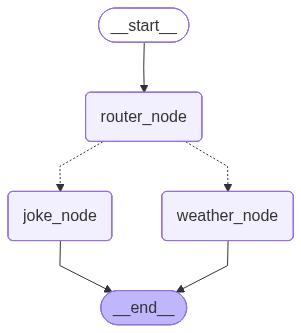

In [6]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## 6. Run It!

In [7]:
# ── Weather path ──────────────────────────────────────────────────────────────
result = graph.invoke({"user_input": "What's the weather like in Paris?"})
print("Final Answer:", result["final_answer"])

[Router] →
INTENT: weather  
CITY: Paris

[Weather Node] Paris: broken clouds, 10.27°C (feels like 9.81°C), humidity 94%

Final Answer: The weather in Paris is currently a bit cloudy with a temperature of 10.3°C, though it feels a little cooler at 9.8°C. It's quite humid at 94%, so you might want a light jacket if you're heading out! Enjoy your day!


In [8]:
# ── Joke path: topic extracted ────────────────────────────────────────────────
result2 = graph.invoke({"user_input": "Tell me a joke about programmers"})
print("Final Answer:", result2["final_answer"])

[Router] →
INTENT: joke  
TOPIC: programmers

[Joke Node] Generating joke about: programmers

Final Answer: Why do programmers prefer dark mode? Because light attracts bugs!


In [9]:
# ── Joke path: general ────────────────────────────────────────────────────────
result3 = graph.invoke({"user_input": "Make me laugh"})
print("Final Answer:", result3["final_answer"])

[Router] →
INTENT: joke
TOPIC: general

[Joke Node] Generating joke about: general

Final Answer: Why did the scarecrow win an award? Because he was outstanding in his field!


In [10]:
# ── Try your own! ─────────────────────────────────────────────────────────────
user_input = "What does London temperature like?"   # change me!
result4 = graph.invoke({"user_input": user_input})
print(f"Intent: {result4['intent']}")
print(f"Final Answer: {result4['final_answer']}")

[Router] →
INTENT: weather  
CITY: London

[Weather Node] London: few clouds, 9.08°C (feels like 6.02°C), humidity 83%

Intent: weather
Final Answer: Today in London, it's a bit chilly with a temperature of 9.08°C, but it feels like 6.02°C due to the humidity. There are a few clouds in the sky, so it’s a great time to bundle up and enjoy a cozy day out!
